In [39]:
!pip install pandas --quiet
!pip install matplotlib --quiet

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_table('salary.txt',sep=r'\s+')
df.head()

,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0
1,2,2,M,Other,91,Other,94,94,Assist,0,4743.0
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0
4,5,6,M,PhD,66,Other,91,91,Full,1,11182.0


In [ ]:
df.shape


(19792, 11)

In [ ]:
all_columns = df.columns
for col_name in all_columns:
    print(f'Col name:{col_name} has {df[col_name].nunique()} values')

Col name:case has 19792 values
Col name:id has 1597 values
Col name:sex has 2 values
Col name:deg has 3 values
Col name:yrdeg has 48 values
Col name:field has 3 values
Col name:startyr has 44 values
Col name:year has 20 values
Col name:rank has 3 values
Col name:admin has 2 values
Col name:salary has 3086 values


In [ ]:
#Rank has 4 NA vals
df.isna().sum()

case       0
id         0
sex        0
deg        0
yrdeg      0
field      0
startyr    0
year       0
rank       4
admin      0
salary     0
dtype: int64

In [29]:
#  Consider both in aggregate, and also stratified by sex.

# Count distribution
field_counts = df['field'].value_counts().sort_values(ascending=False)

# Percent distribution
field_percent = df['field'].value_counts(normalize=True).sort_values(ascending=False) * 100

overall_table = pd.DataFrame({
    'Count': field_counts,
    'Percent': field_percent.round(2)
})

print(overall_table)

print("Number of unique fields:", df['field'].nunique())

# Mode (most common field)
print("Most common field:", df['field'].mode()[0])



       Count  Percent
field                
Other  13143    66.41
Prof    3809    19.25
Arts    2840    14.35
Number of unique fields: 3
Most common field: Other


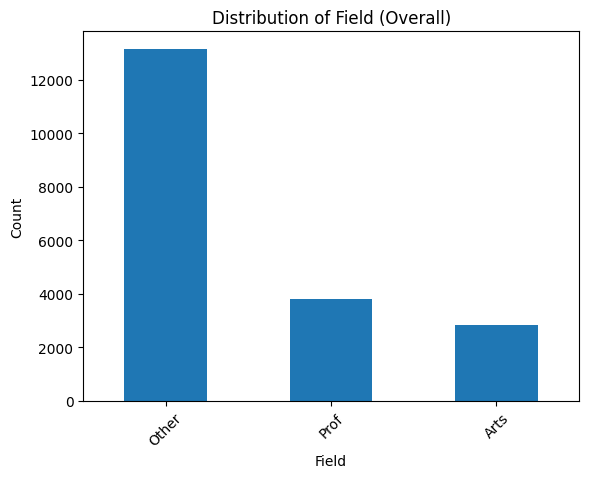

In [32]:
plt.figure()
field_counts.plot(kind='bar')
plt.xlabel("Field")
plt.ylabel("Count")
plt.title("Distribution of Field (Overall)")
plt.xticks(rotation=45)
plt.show()


In [42]:
df[df['year']==95]

,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0
8,9,6,M,PhD,66,Other,91,95,Full,0,12184.0
28,29,7,M,PhD,70,Other,71,95,Assoc,0,4604.0
...,...,...,...,...,...,...,...,...,...,...,...
19736,19737,1766,M,Other,55,Arts,68,95,Full,1,7593.0
19741,19742,1767,M,Other,56,Arts,91,95,Full,0,7823.0
19752,19753,1768,F,Other,70,Arts,85,95,Assoc,0,4292.0
19771,19772,1769,M,Other,57,Arts,77,95,Full,0,7494.0


In [45]:
df[df['year']==95]

,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0
8,9,6,M,PhD,66,Other,91,95,Full,0,12184.0
28,29,7,M,PhD,70,Other,71,95,Assoc,0,4604.0
...,...,...,...,...,...,...,...,...,...,...,...
19736,19737,1766,M,Other,55,Arts,68,95,Full,1,7593.0
19741,19742,1767,M,Other,56,Arts,91,95,Full,0,7823.0
19752,19753,1768,F,Other,70,Arts,85,95,Assoc,0,4292.0
19771,19772,1769,M,Other,57,Arts,77,95,Full,0,7494.0


In [47]:
cols_to_stratify = ['field','startyr','rank','salary']

def stratification_by_sex(df, colname:str, year=0):
    if year!=0:
        df = df[df['year']==year]
    cross_counts = pd.crosstab(df[colname], df['sex'])
    print(cross_counts)
    cross_percent = pd.crosstab(df[colname], df['sex'],normalize='columns'
    ) * 100
    print(cross_percent.round(2))
    print("===========================================================================")


stratification_by_sex(df,'field')
stratification_by_sex(df,'yrdeg')

stratification_by_sex(df,'startyr')
stratification_by_sex(df,'rank',year = 95)
stratification_by_sex(df,'salary',year = 95)


sex       F      M
field             
Arts    802   2038
Other  2735  10408
Prof    389   3420
sex        F      M
field              
Arts   20.43  12.85
Other  69.66  65.60
Prof    9.91  21.56
sex      F    M
yrdeg          
48       0   14
49       0   19
50       0   18
51       0   25
53       0   34
54      20   60
55      20  139
56      20  147
57       0  229
58      19  232
59      39  219
60      20  367
61      40  525
62      20  273
63      19  471
64      38  559
65      66  590
66      59  637
67      84  956
68     117  829
69     111  855
70     189  782
71     201  785
72     135  913
73     208  745
74     339  553
75     166  601
76     134  349
77     159  557
78     118  561
79     117  325
80     113  334
81     190  320
82     164  305
83     117  278
84     105  237
85     128  252
86     118  128
87      94  126
88      70  140
89      72   92
90      92  102
91      79   60
92      67   75
93      43   23
94      14   20
95       2    4
96       0    1
sex  